## Agrupación de IPs por sus palabras clave

Paso 1: Cargar el dataset

In [1]:
import pandas as pd

df = pd.read_csv("Keywords/author_keyword_matrix.csv", index_col=0)

# Mostrar resumen
print("✅ Dataset generado con forma:", df.shape)
print("🔢 Palabras clave totales:", len(df.columns))
print("👥 Autores con keywords:", len(df))

✅ Dataset generado con forma: (29, 3324)
🔢 Palabras clave totales: 3324
👥 Autores con keywords: 29


Paso 2: Preprocesamiento (normalización y reducción PCA)

In [2]:
from sklearn.preprocessing import Normalizer
from sklearn.decomposition import PCA

X = df.values
X_normalized = Normalizer().fit_transform(X)

Paso 3: Clustering con Spectral Clustering

In [3]:
# === Configuraciones de preprocesamiento y clustering ===
pca_dims = [2, 5, 10, 20]
k_values = list(range(2, 16))

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import Normalizer, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Evaluar KMeans para k entre 2 y 15
results = []

# === Estudio con GMM ===
for n_dim in pca_dims:
    X_reduced = PCA(n_components=n_dim).fit_transform(X_normalized)

    for k in k_values:
        try:
            model = GaussianMixture(n_components=k, random_state=42)
            labels = model.fit_predict(X_reduced)

            silhouette = silhouette_score(X_reduced, labels)
            ch_score = calinski_harabasz_score(X_reduced, labels)
            db_score = davies_bouldin_score(X_reduced, labels)

            results.append({
                "PCA_dims": n_dim,
                "k": k,
                "Silhouette": silhouette,
                "Calinski-Harabasz": ch_score,
                "Davies-Bouldin": db_score,
                "Labels": labels
            })

        except Exception as e:
            results.append({
                "PCA_dims": n_dim,
                "k": k,
                "Silhouette": np.nan,
                "Calinski-Harabasz": np.nan,
                "Davies-Bouldin": np.nan,
                "Error": str(e),
                "Labels": []
            })

# === Análisis de resultados ===
df_results = pd.DataFrame(results).dropna(subset=["Silhouette"])
print("✅ Resultados de clustering generados con forma:", df_results.shape)
print("🔍 Resultados de clustering:", df_results.head())

✅ Resultados de clustering generados con forma: (56, 6)
🔍 Resultados de clustering:    PCA_dims  k  Silhouette  Calinski-Harabasz  Davies-Bouldin  \
0         2  2    0.449208          16.274437        0.659649   
1         2  3    0.612660          49.858519        0.562500   
2         2  4    0.593785          57.261038        0.493284   
3         2  5    0.620942          83.935536        0.528309   
4         2  6    0.658017          94.330087        0.414852   

                                              Labels  
0  [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, ...  
1  [2, 0, 0, 2, 1, 2, 0, 2, 2, 2, 0, 1, 1, 0, 0, ...  
2  [3, 0, 0, 2, 1, 2, 0, 3, 3, 3, 0, 1, 1, 0, 0, ...  
3  [3, 0, 0, 2, 1, 2, 0, 3, 3, 3, 0, 1, 1, 4, 4, ...  
4  [3, 5, 5, 2, 1, 2, 0, 3, 3, 3, 0, 1, 1, 4, 4, ...  


In [5]:
metrics = df_results[["Silhouette", "Calinski-Harabasz", "Davies-Bouldin"]].copy()
metrics["Davies-Bouldin"] = -metrics["Davies-Bouldin"]
scaled = pd.DataFrame(MinMaxScaler().fit_transform(metrics), columns=metrics.columns)

df_results["score_combined"] = (
    0.8 * scaled["Silhouette"] +
    0.1 * scaled["Calinski-Harabasz"] +
    0.1 * scaled["Davies-Bouldin"]
)

best_per_k = (
    df_results
    .sort_values("score_combined", ascending=False)
    .drop_duplicates(subset=["k"])
    .sort_values("k")
)

# Mostrar resumen
print("✅ Mejores configuraciones por número de clusters:")
print(best_per_k[["PCA_dims", "k", "Silhouette", "Calinski-Harabasz", "Davies-Bouldin", "score_combined"]])

✅ Mejores configuraciones por número de clusters:
    PCA_dims   k  Silhouette  Calinski-Harabasz  Davies-Bouldin  \
0          2   2    0.449208          16.274437        0.659649   
1          2   3    0.612660          49.858519        0.562500   
2          2   4    0.593785          57.261038        0.493284   
3          2   5    0.620942          83.935536        0.528309   
4          2   6    0.658017          94.330087        0.414852   
19         5   7    0.681146          45.913968        0.403852   
20         5   8    0.741130          57.336422        0.306881   
21         5   9    0.725765          71.829120        0.355439   
22         5  10    0.703369          80.732516        0.409545   
37        10  11    0.729364          32.378137        0.397230   
38        10  12    0.698974          39.972477        0.296327   
39        10  13    0.659447          38.234216        0.275064   
40        10  14    0.623408          40.696189        0.324407   
41        10

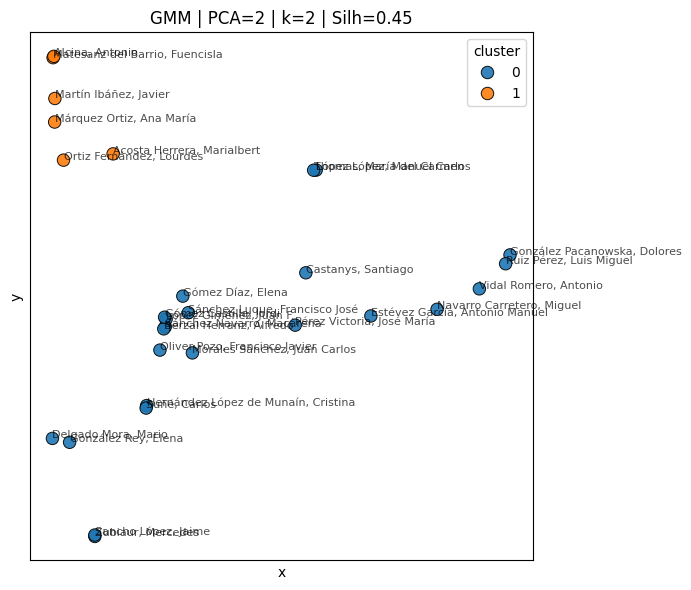

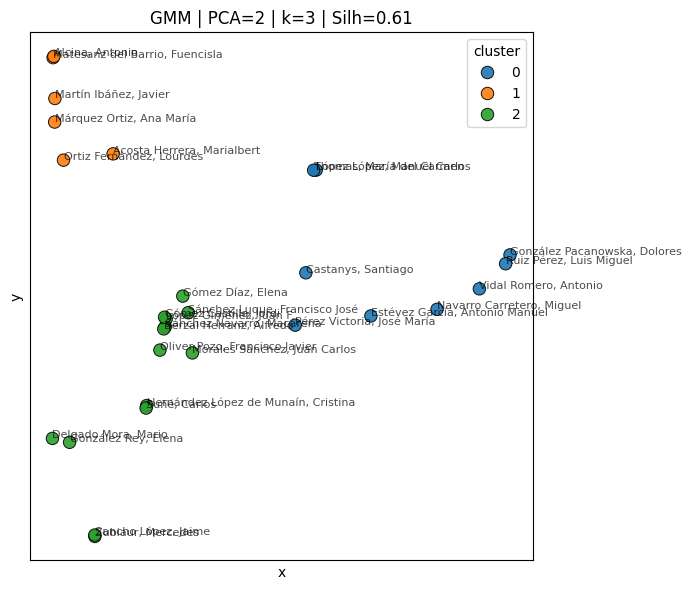

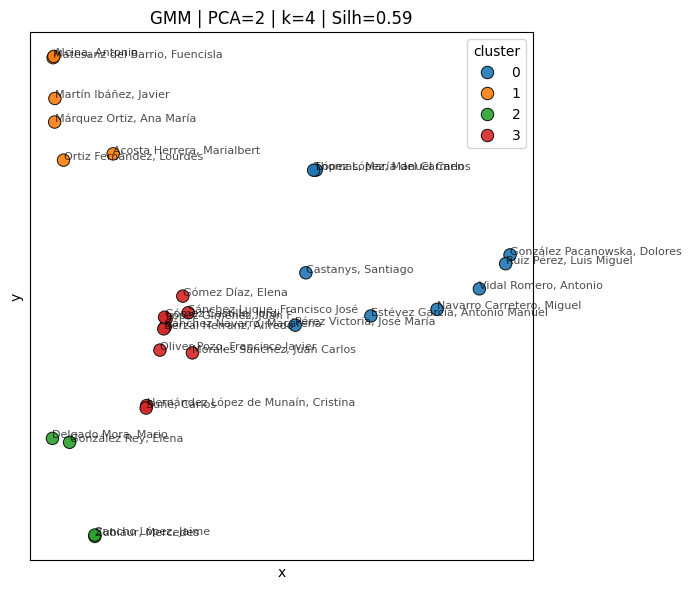

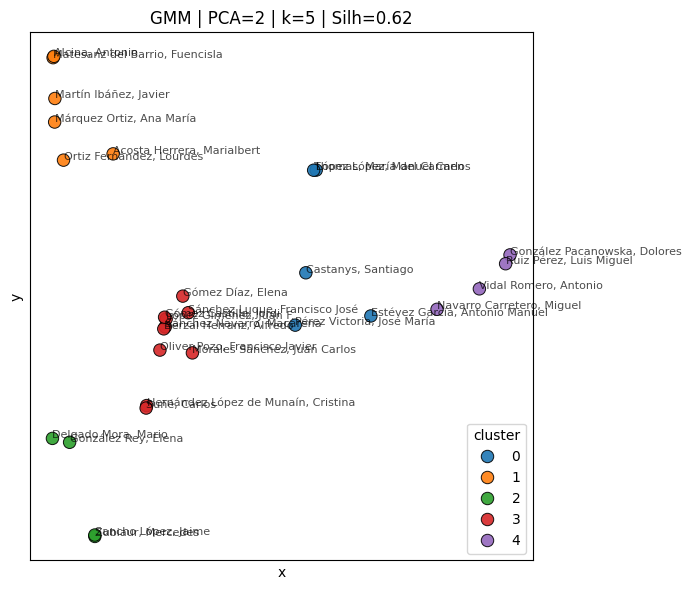

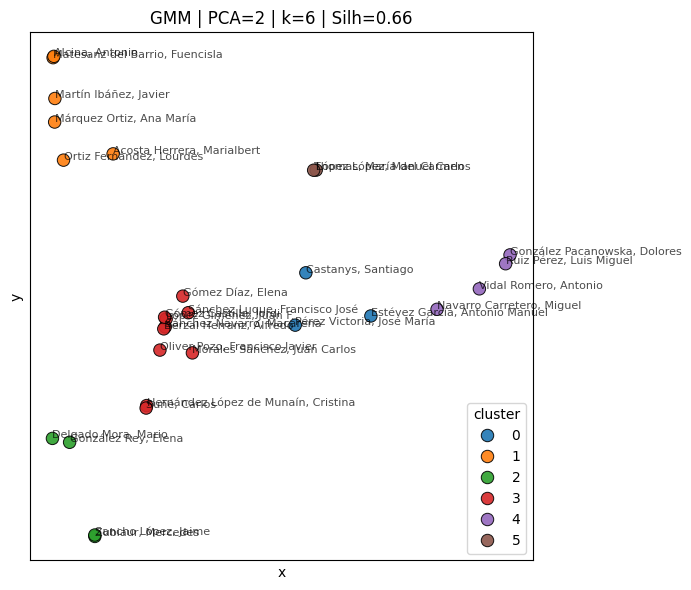

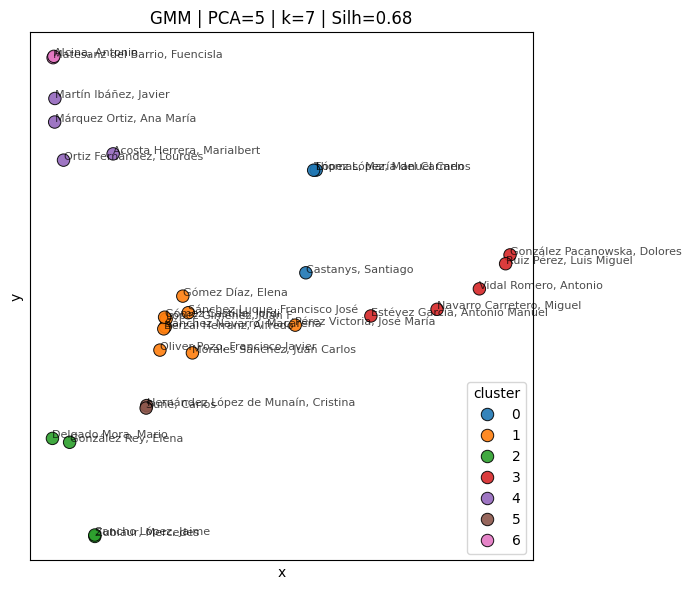

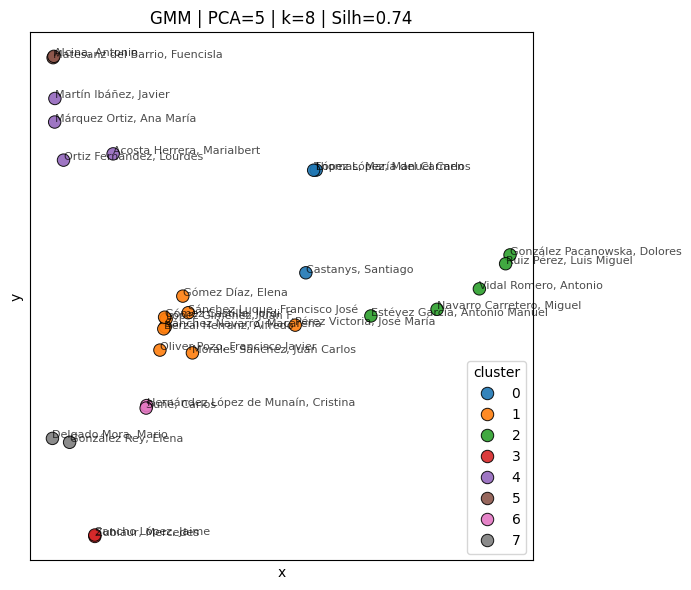

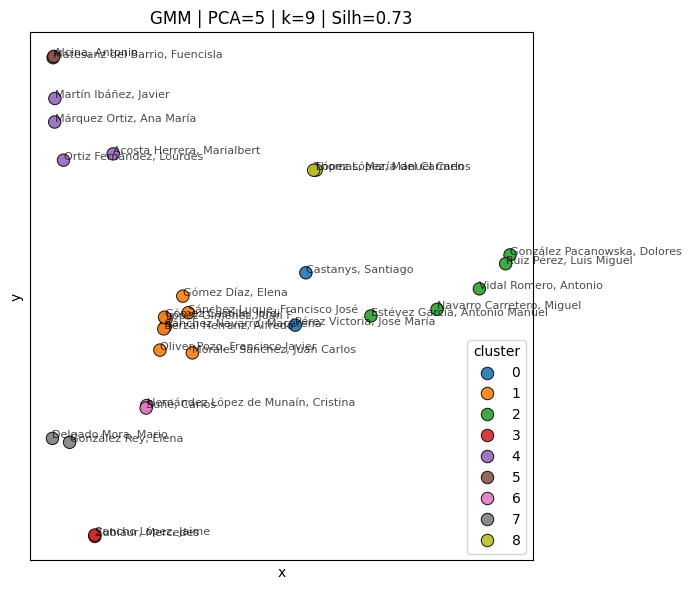

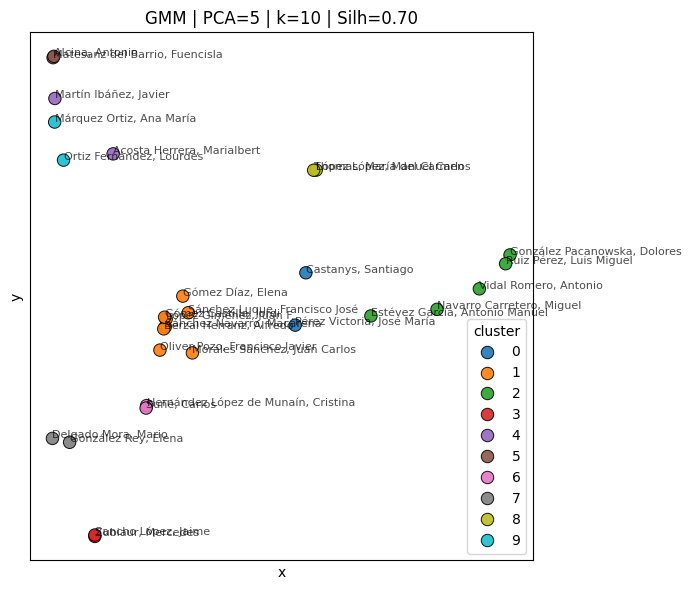

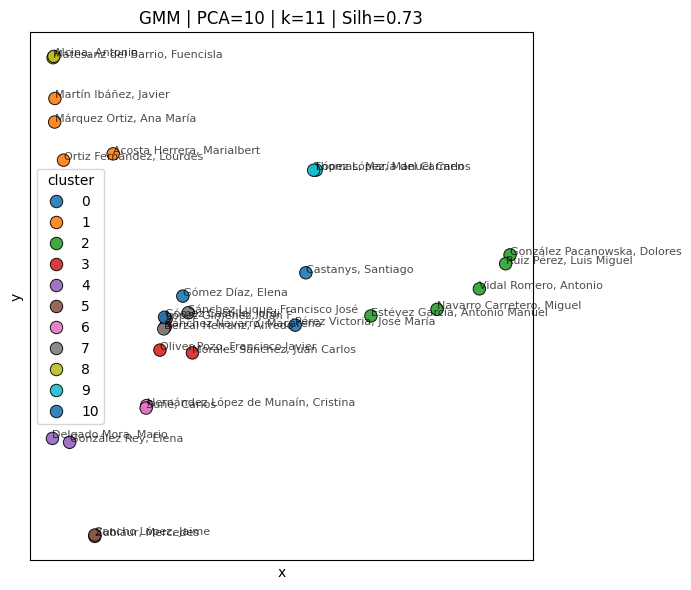

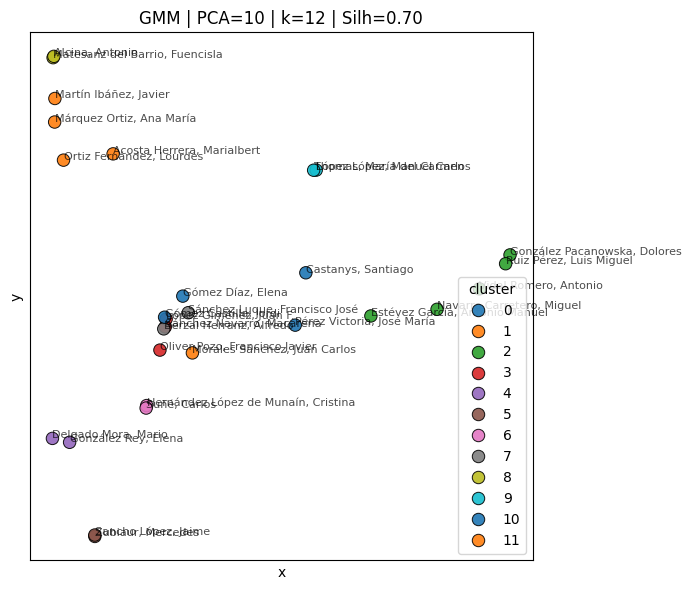

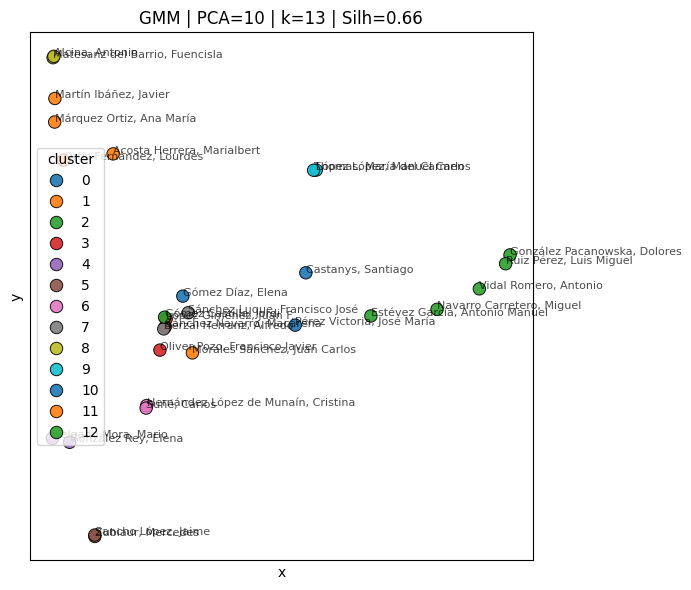

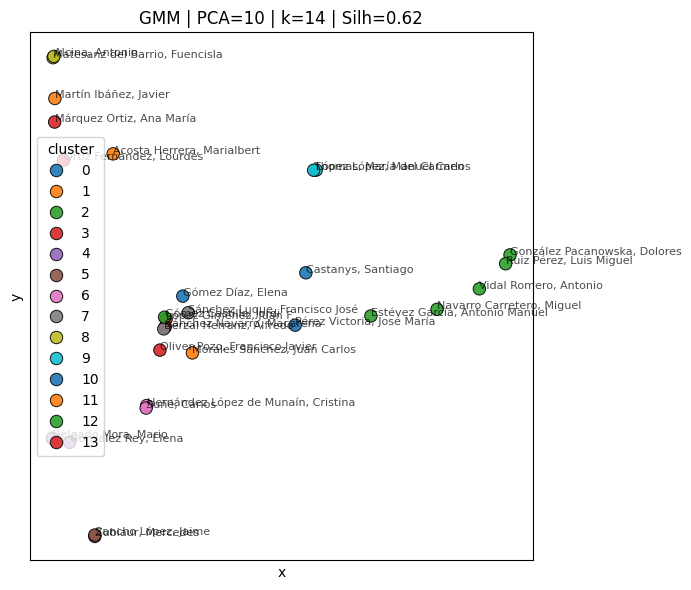

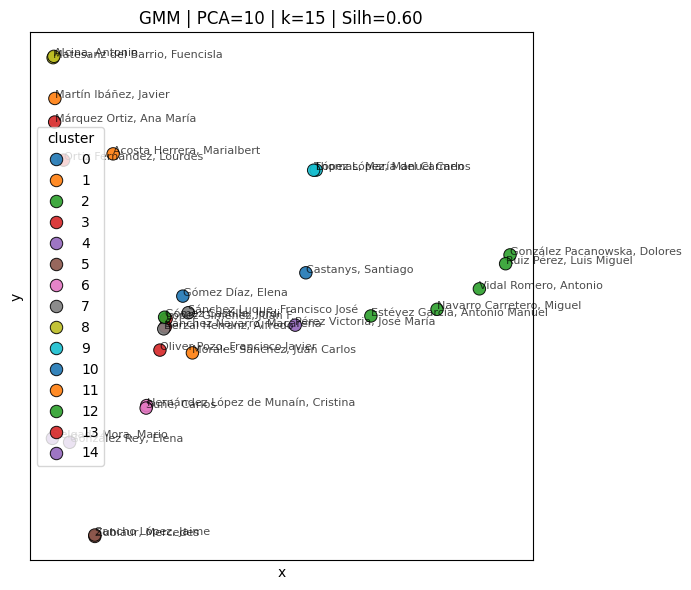

In [6]:
# === Visualización ===
X_2d = PCA(n_components=2).fit_transform(X_normalized)

for _, row in best_per_k.iterrows():
    labels = row["Labels"]
    coords_df = pd.DataFrame(X_2d, columns=["x", "y"])
    coords_df["author"] = df.index
    coords_df["cluster"] = labels

    plt.figure(figsize=(7, 6))
    sns.scatterplot(data=coords_df, x="x", y="y", hue="cluster", palette="tab10", s=80, edgecolor='k', alpha=0.9)
    for _, r in coords_df.iterrows():
        plt.text(r["x"], r["y"], r["author"], fontsize=8, alpha=0.7)

    plt.title(f"GMM | PCA={row['PCA_dims']} | k={row['k']} | Silh={row['Silhouette']:.2f}")
    plt.xticks([]); plt.yticks([])
    plt.tight_layout()
    plt.show()

Guardamos los resultados

In [7]:
# === Guardar resultados ===
cluster_records = []

for _, row in best_per_k.iterrows():
    for author, cluster in zip(df.index, row["Labels"]):
        cluster_records.append({
            "author": author,
            "cluster": int(cluster),
            "k": row["k"],
            "pca_dims": row["PCA_dims"],
            "silhouette": row["Silhouette"],
            "calinski_harabasz": row["Calinski-Harabasz"],
            "davies_bouldin": row["Davies-Bouldin"]
        })

pd.DataFrame(cluster_records).to_csv("Keywords/GMM/gmm_best_configs.csv", index=False)